# Record Pairs Exploration

Detailed exploration notebook for image/LabelMe JSON record pairs in `data/record_pairs`.

This notebook computes:
- pair integrity (matching image/json stems)
- image-level stats (count, dimensions, file sizes)
- annotation-level stats (total, per-image distribution)
- label and shape-type distributions
- polygon point-count distribution


In [1]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('ggplot')
pd.set_option('display.max_rows', 100)
pd.set_option('display.max_columns', 100)


In [2]:
# Resolve dataset directory from repository root or current working dir
candidates = [
    Path.cwd() / 'data' / 'record_pairs',
    Path.cwd() / 'record_pairs',
]

data_dir = None
for c in candidates:
    if c.exists() and c.is_dir():
        data_dir = c
        break

if data_dir is None:
    raise FileNotFoundError('Could not locate record_pairs directory.')

data_dir


PosixPath('/home/schelli/git/wtcv/data/record_pairs')

In [3]:
json_files = sorted(data_dir.glob('*.json'))
img_files = sorted(data_dir.glob('*.png'))

json_stems = {p.stem for p in json_files}
img_stems = {p.stem for p in img_files}

paired_stems = sorted(json_stems & img_stems)
missing_json = sorted(img_stems - json_stems)
missing_images = sorted(json_stems - img_stems)

pair_summary = pd.DataFrame({
    'metric': [
        'json_files',
        'image_files_png',
        'paired_records',
        'images_missing_json',
        'json_missing_image',
    ],
    'value': [
        len(json_files),
        len(img_files),
        len(paired_stems),
        len(missing_json),
        len(missing_images),
    ]
})

pair_summary


,metric,value
0,json_files,224
1,image_files_png,224
2,paired_records,224
3,images_missing_json,0
4,json_missing_image,0


In [4]:
# Parse JSON metadata + shapes into dataframes
records = []
shapes = []

for jf in json_files:
    d = json.loads(jf.read_text())
    stem = jf.stem
    img_path = data_dir / f'{stem}.png'

    shape_list = d.get('shapes', []) or []

    records.append({
        'stem': stem,
        'json_file': jf.name,
        'image_file': img_path.name if img_path.exists() else None,
        'image_width': d.get('imageWidth'),
        'image_height': d.get('imageHeight'),
        'annotation_count': len(shape_list),
        'json_size_bytes': jf.stat().st_size,
        'image_size_bytes': img_path.stat().st_size if img_path.exists() else np.nan,
    })

    for i, s in enumerate(shape_list):
        points = s.get('points') or []
        xs = [p[0] for p in points if isinstance(p, list) and len(p) == 2]
        ys = [p[1] for p in points if isinstance(p, list) and len(p) == 2]

        shapes.append({
            'stem': stem,
            'shape_idx': i,
            'label': s.get('label'),
            'shape_type': s.get('shape_type'),
            'num_points': len(points),
            'min_x': min(xs) if xs else np.nan,
            'max_x': max(xs) if xs else np.nan,
            'min_y': min(ys) if ys else np.nan,
            'max_y': max(ys) if ys else np.nan,
        })

df_records = pd.DataFrame(records).sort_values('stem').reset_index(drop=True)
df_shapes = pd.DataFrame(shapes).sort_values(['stem', 'shape_idx']).reset_index(drop=True)

df_records.head()


,stem,json_file,image_file,image_width,image_height,annotation_count,json_size_bytes,image_size_bytes
0,000055,000055.json,000055.png,1280,720,1,759,1582675
1,000057,000057.json,000057.png,1280,720,1,1011,1586725
2,000059,000059.json,000059.png,1280,720,1,817,1585604
3,000061,000061.json,000061.png,1280,720,1,817,1585374
4,000063,000063.json,000063.png,1280,720,1,875,1681995


In [5]:
annotation_counts = df_records['annotation_count'].to_numpy()
point_counts = df_shapes['num_points'].to_numpy() if len(df_shapes) else np.array([])

summary = pd.DataFrame([
    {'metric': 'records_total', 'value': len(df_records)},
    {'metric': 'images_total_png', 'value': len(img_files)},
    {'metric': 'paired_records', 'value': len(paired_stems)},
    {'metric': 'annotations_total', 'value': int(df_records['annotation_count'].sum())},
    {'metric': 'annotations_per_image_min', 'value': int(df_records['annotation_count'].min())},
    {'metric': 'annotations_per_image_mean', 'value': float(df_records['annotation_count'].mean())},
    {'metric': 'annotations_per_image_median', 'value': float(df_records['annotation_count'].median())},
    {'metric': 'annotations_per_image_max', 'value': int(df_records['annotation_count'].max())},
    {'metric': 'annotations_per_image_p90', 'value': float(np.quantile(annotation_counts, 0.90))},
    {'metric': 'annotations_per_image_p95', 'value': float(np.quantile(annotation_counts, 0.95))},
    {'metric': 'annotations_per_image_p99', 'value': float(np.quantile(annotation_counts, 0.99))},
    {'metric': 'images_with_zero_annotations', 'value': int((df_records['annotation_count'] == 0).sum())},
    {'metric': 'unique_image_widths', 'value': sorted(df_records['image_width'].dropna().unique().tolist())},
    {'metric': 'unique_image_heights', 'value': sorted(df_records['image_height'].dropna().unique().tolist())},
    {'metric': 'polygon_points_min', 'value': int(point_counts.min()) if len(point_counts) else np.nan},
    {'metric': 'polygon_points_mean', 'value': float(point_counts.mean()) if len(point_counts) else np.nan},
    {'metric': 'polygon_points_median', 'value': float(np.median(point_counts)) if len(point_counts) else np.nan},
    {'metric': 'polygon_points_max', 'value': int(point_counts.max()) if len(point_counts) else np.nan},
])

summary


,metric,value
0,records_total,224
1,images_total_png,224
2,paired_records,224
3,annotations_total,337
4,annotations_per_image_min,1
5,annotations_per_image_mean,1.504464
6,annotations_per_image_median,1.0
7,annotations_per_image_max,5
8,annotations_per_image_p90,3.0
9,annotations_per_image_p95,3.85


In [6]:
label_counts = (
    df_shapes['label']
    .fillna('<missing>')
    .value_counts()
    .rename_axis('label')
    .reset_index(name='count')
)
label_counts['pct'] = 100 * label_counts['count'] / label_counts['count'].sum()
label_counts


,label,count,pct
0,vehicle,337,100.0


In [7]:
shape_type_counts = (
    df_shapes['shape_type']
    .fillna('<missing>')
    .value_counts()
    .rename_axis('shape_type')
    .reset_index(name='count')
)
shape_type_counts['pct'] = 100 * shape_type_counts['count'] / shape_type_counts['count'].sum()
shape_type_counts


,shape_type,count,pct
0,polygon,337,100.0


In [8]:
annotation_hist = (
    df_records['annotation_count']
    .value_counts()
    .sort_index()
    .rename_axis('annotation_count')
    .reset_index(name='num_images')
)
annotation_hist['pct_images'] = 100 * annotation_hist['num_images'] / len(df_records)
annotation_hist


,annotation_count,num_images,pct_images
0,1,151,67.410714
1,2,49,21.875000
2,3,12,5.357143
3,4,8,3.571429
4,5,4,1.785714


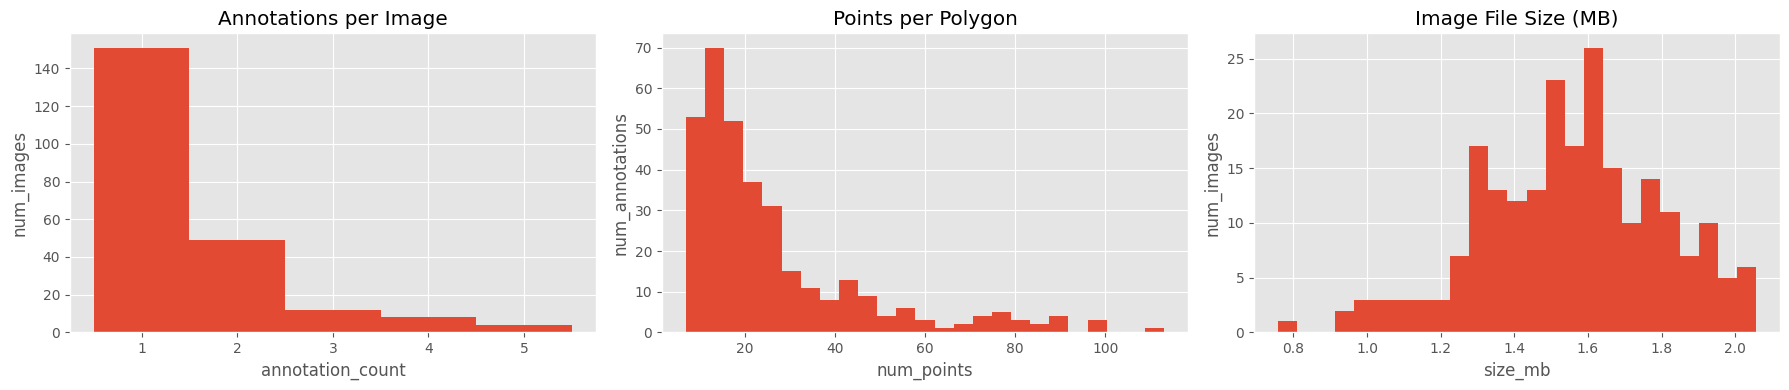

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].hist(
    df_records['annotation_count'],
    bins=np.arange(df_records['annotation_count'].min(), df_records['annotation_count'].max() + 2) - 0.5
)
axes[0].set_title('Annotations per Image')
axes[0].set_xlabel('annotation_count')
axes[0].set_ylabel('num_images')

if len(df_shapes):
    axes[1].hist(df_shapes['num_points'], bins=25)
axes[1].set_title('Points per Polygon')
axes[1].set_xlabel('num_points')
axes[1].set_ylabel('num_annotations')

img_size_mb = df_records['image_size_bytes'] / (1024 ** 2)
axes[2].hist(img_size_mb.dropna(), bins=25)
axes[2].set_title('Image File Size (MB)')
axes[2].set_xlabel('size_mb')
axes[2].set_ylabel('num_images')

plt.tight_layout()
plt.show()
